# Experiments

In [45]:
import argparse
import os
import warnings
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings('ignore')

from src.data import load_dataset, make_ssl_split, preprocess
from src.model import make_mlp, train_model, predict_proba_nn, get_metrics_nn
from src.metrics import compute_metrics
from src.ssl_methods import (
    run_vanilla_pl,
    run_ups,
    run_adaptive_ufssl,
    run_ufssl_weighted,
    run_champion,
    run_stage7,
)
from src.plots import (
    plot_vpl_dynamics,
    plot_calibration,
    plot_entropy_distribution,
)

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


## Helper functions

In [46]:
def section(title):
    print(f'\n{title}')
    print('-' * len(title))


def summarize_split(X_labeled, X_unlabeled, X_test):
    summary = pd.DataFrame({
        'split': ['labeled', 'unlabeled', 'test'],
        'samples': [len(X_labeled), len(X_unlabeled), len(X_test)],
        'share': ['10%', '40%', '50%']
    })
    return summary


def metrics_row(name, metrics):
    return {
        'method': name,
        'accuracy': metrics['accuracy'],
        'f1': metrics['f1'],
        'auc': metrics['auc'],
        'fnr': metrics['fnr'],
        'brier': metrics['brier'],
        'ece': metrics['ece'],
    }


def show_metric_line(name, metrics):
    print(
        f"{name:<36} "
        f"Acc={metrics['accuracy']:.4f}  "
        f"F1={metrics['f1']:.4f}  "
        f"AUC={metrics['auc']:.4f}  "
        f"FNR={metrics['fnr']:.4f}"
    )


## Load data and create SSL split

In [47]:
X, y = load_dataset()

X_labeled, X_unlabeled, X_test, y_labeled, y_unlabeled, y_test = make_ssl_split(
    X, y, labeled_ratio=0.10, test_ratio=0.50, seed=SEED
)

X_lab_sc, X_unlab_sc, X_test_sc, _ = preprocess(X_labeled, X_unlabeled, X_test)

section('Data split')
split_df = summarize_split(X_labeled, X_unlabeled, X_test)
display(split_df)


Dataset Overview:
  Features : 30
  Samples  : 569
  Classes  : malignant=212, benign=357

Data split
----------


,split,samples,share
0,labeled,56,10%
1,unlabeled,228,40%
2,test,285,50%


## Supervised baselines

In [48]:
section('Supervised baselines')

model_sup = make_mlp(SEED)
train_model(model_sup, X_lab_sc, y_labeled, n_epochs=100, seed=SEED)
metrics_sup = get_metrics_nn(model_sup, X_test_sc, y_test)
show_metric_line('MLP (supervised only)', metrics_sup)

probs_sup_mlp = predict_proba_nn(model_sup, X_test_sc)
y_prob_sup = probs_sup_mlp[:, 1]


Supervised baselines
--------------------
MLP (supervised only)                Acc=0.9614  F1=0.9589  AUC=0.9972  FNR=0.0377


## SSL experiments

In [49]:
section('SSL experiments')

_, history_vpl, metrics_vpl = run_vanilla_pl(
    X_lab_sc, y_labeled, X_unlab_sc, X_test_sc, y_test, seed=SEED
)
show_metric_line('Vanilla pseudo-labeling', metrics_vpl)

_, history_ups, metrics_ups = run_ups(
    X_lab_sc, y_labeled, X_unlab_sc, X_test_sc, y_test, seed=SEED
)
show_metric_line('UPS', metrics_ups)

_, history_ufssl, metrics_ufssl = run_adaptive_ufssl(
    X_lab_sc, y_labeled, X_unlab_sc, X_test_sc, y_test, seed=SEED
)
show_metric_line('Adaptive UF-SSL', metrics_ufssl)

_, history_wt, metrics_weighted = run_ufssl_weighted(
    X_lab_sc, y_labeled, X_unlab_sc, X_test_sc, y_test, seed=SEED
)
show_metric_line('Adaptive UF-SSL + weighted loss', metrics_weighted)

_, history_champ, metrics_champion = run_champion(
    X_lab_sc, y_labeled, X_unlab_sc, X_test_sc, y_test, seed=SEED
)
show_metric_line('Cost-sensitive asymmetric UF-SSL', metrics_champion)

_, history_s7, metrics_stage7 = run_stage7(
    X_lab_sc, y_labeled, X_unlab_sc, X_test_sc, y_test,
    seed=SEED, target_fnr=metrics_sup['fnr']
)
show_metric_line('Stage 7 defer gate UF-SSL', metrics_stage7)



SSL experiments
---------------

  tau=0.95 | epochs/round=50 | max_rounds=10
  Starting labeled pool: 56 samples

  Round  1: selected=187, train_size=243, pool_left= 41, acc=0.9719, fnr=0.0283
  Round  2: selected= 31, train_size=274, pool_left= 10, acc=0.9754, fnr=0.0472
  Round  3: selected=  5, train_size=279, pool_left=  5, acc=0.9719, fnr=0.0472
  Round  4: selected=  4, train_size=283, pool_left=  1, acc=0.9719, fnr=0.0472
  Round  5: selected=  1, train_size=284, pool_left=  0, acc=0.9719, fnr=0.0472
  Round 6: unlabeled pool exhausted.
Vanilla pseudo-labeling              Acc=0.9684  F1=0.9660  AUC=0.9951  FNR=0.0566
  tau=0.95 | sigma=0.05 | T=30 | max_rounds=10
  Starting labeled pool: 56 samples

  Round  1: conf_pass=179, dual_pass=176, rej_by_sigma=  3, pool_left= 52, acc=0.9684, fnr=0.0283
  Round  2: conf_pass= 33, dual_pass= 26, rej_by_sigma=  7, pool_left= 26, acc=0.9825, fnr=0.0189
  Round  3: conf_pass= 11, dual_pass=  9, rej_by_sigma=  2, pool_left= 17, acc=0.971

## Final results table

In [50]:
results_df = pd.DataFrame([
    metrics_row('MLP supervised only', metrics_sup),
    metrics_row('Vanilla pseudo-labeling', metrics_vpl),
    metrics_row('UPS', metrics_ups),
    metrics_row('Adaptive UF-SSL', metrics_ufssl),
    metrics_row('Adaptive UF-SSL + weighted loss', metrics_weighted),
    metrics_row('Cost-sensitive asymmetric UF-SSL', metrics_champion),
    metrics_row('Stage 7 FNR-driven defer gate', metrics_stage7),
])

results_df.style.format({
    'accuracy': '{:.4f}',
    'f1': '{:.4f}',
    'auc': '{:.4f}',
    'fnr': '{:.4f}',
    'brier': '{:.4f}',
    'ece': '{:.4f}',
})


,method,accuracy,f1,auc,fnr,brier,ece
0,MLP supervised only,0.9614,0.9589,0.9972,0.0377,0.0244,0.0206
1,Vanilla pseudo-labeling,0.9684,0.9660,0.9951,0.0566,0.0255,0.0278
2,UPS,0.9649,0.9624,0.9901,0.0472,0.0326,0.0334
3,Adaptive UF-SSL,0.9614,0.9589,0.9862,0.0377,0.0335,0.0355
4,Adaptive UF-SSL + weighted loss,0.9684,0.9661,0.9977,0.0472,0.0255,0.0278
5,Cost-sensitive asymmetric UF-SSL,0.9754,0.9737,0.9949,0.0377,0.0216,0.0222
6,Stage 7 FNR-driven defer gate,0.9789,0.9776,0.9982,0.0189,0.0186,0.0191


**Notes**

- FNR = false negative rate. 
- Brier score and ECE measure calibration. 

## Plots


Plots
-----


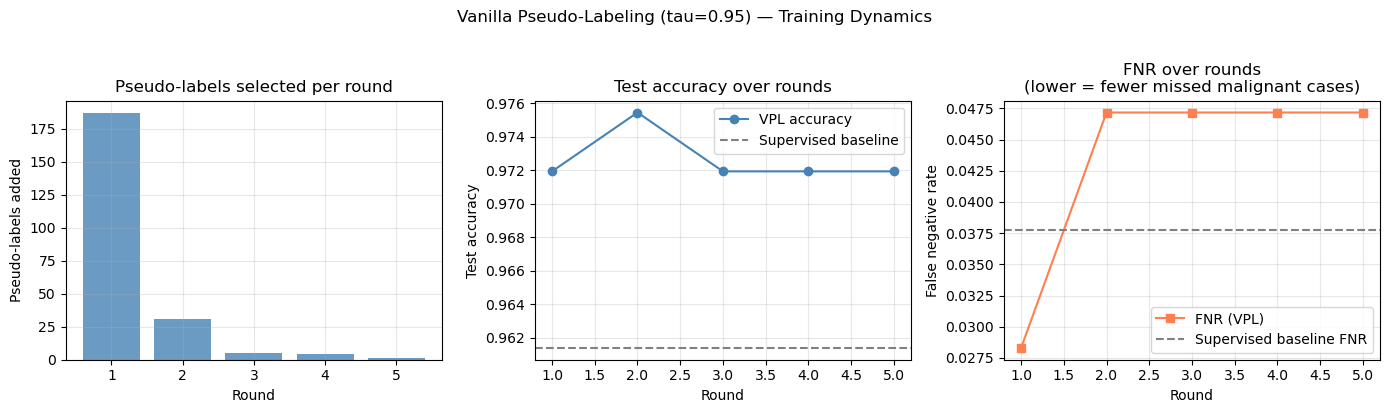

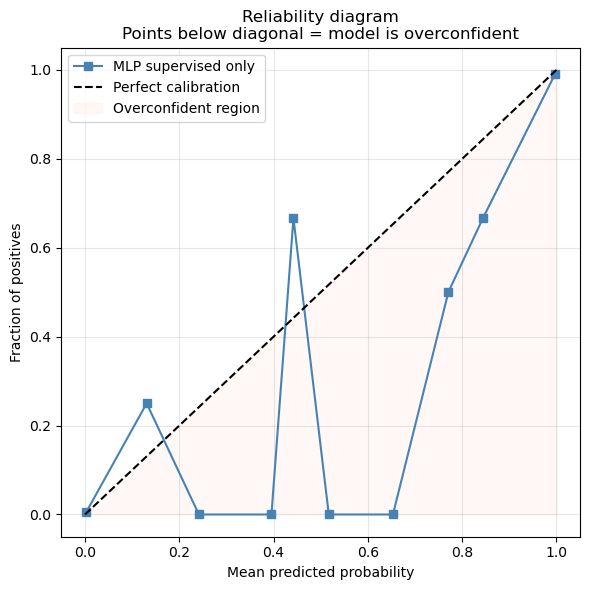

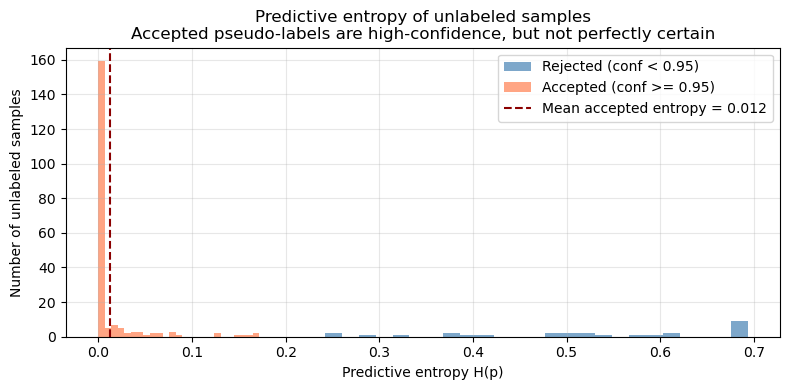


Entropy stats for accepted samples (conf >= 0.95):
  Count: 200
  Mean entropy: 0.0123
  Max entropy: 0.1719
  % with H > 0.10: 3.5%


In [51]:
section('Plots')
plot_vpl_dynamics(history_vpl, metrics_sup)
plot_calibration(y_test, y_prob_sup)

probs_unlab = predict_proba_nn(model_sup, X_unlab_sc)
plot_entropy_distribution(probs_unlab, tau=0.95)
